In [10]:
import numpy as np
import pandas as pd

In [57]:
df_raw = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [58]:
df_raw.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
788,28,No,Travel_Rarely,857,Research & Development,10,3,Other,1,1097,...,4,80,0,10,4,4,8,7,1,7
197,42,No,Non-Travel,926,Research & Development,21,2,Medical,1,270,...,2,80,1,11,5,3,5,3,0,2
1023,56,No,Travel_Rarely,1255,Research & Development,1,2,Life Sciences,1,1441,...,4,80,1,5,3,4,3,2,1,0
1360,31,No,Travel_Rarely,471,Research & Development,4,3,Medical,1,1916,...,2,80,1,4,0,2,2,2,2,2
1218,41,No,Travel_Rarely,918,Sales,6,3,Marketing,1,1708,...,2,80,0,10,3,3,10,8,8,7


In [59]:
keep = [
    'Age', 'DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction',
    'Department', 'Gender', 'MaritalStatus'
]

In [60]:
df = df_raw[keep]

In [61]:
df

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,Department,Gender,MaritalStatus
0,41,1102,1,2,Sales,Female,Single
1,49,279,8,3,Research & Development,Male,Married
2,37,1373,2,4,Research & Development,Male,Single
3,33,1392,3,4,Research & Development,Female,Married
4,27,591,2,1,Research & Development,Male,Married
...,...,...,...,...,...,...,...
1465,36,884,23,3,Research & Development,Male,Married
1466,39,613,6,4,Research & Development,Male,Married
1467,27,155,4,2,Research & Development,Male,Married
1468,49,1023,2,4,Sales,Male,Married


In [15]:
np.random.choice([1, 5])

5

In [17]:
def choose_from_col(data, col):
    return np.random.choice(data[col].unique().tolist())

In [ ]:
def generate(data, seed_column):
    vals = []
    chosen = [seed_column]
    seed_u = data[seed_column].unique().tolist()
    val = choose_from_col(data, seed_column)
    vals.append(val)
    
    for col in data.columns.tolist():
        if col not in chosen:
            temp = data[data[seed_column] == val]
            col_vals = df[col].unique().tolist()
            
        
    

In [18]:
import pandas as pd
import numpy as np

def filter_and_fill_dict(df, initial_col):
    d = {}
    
    def recursive_filter(current_df, chosen_col):
        if chosen_col not in d:
            # Get all unique values from the current column
            unique_values = current_df[chosen_col].unique()
            
            # Choose one random value from unique values
            chosen_value = np.random.choice(unique_values)
            d[chosen_col] = chosen_value
            
            # Filter the dataframe based on the chosen column and value
            filtered_df = current_df[current_df[chosen_col] == chosen_value]
            
            # Find the next column to process
            remaining_cols = [col for col in filtered_df.columns if col not in d]
            if remaining_cols:
                next_col = remaining_cols[0]
                recursive_filter(filtered_df, next_col)
    
    # Start the process with the initial column
    recursive_filter(df, initial_col)
    return d

In [25]:
df = pd.DataFrame({
     'A': [1, 1, 2, 2, 3, 3, 4, 4],
     'B': ['x', 'y', 'x', 'y', 'x', 'y', 'x', 'y'],
     'C': range(10, 18)
 })

In [26]:
df

,A,B,C
0,1,x,10
1,1,y,11
2,2,x,12
3,2,y,13
4,3,x,14
5,3,y,15
6,4,x,16
7,4,y,17


In [33]:
result = filter_and_fill_dict(df, 'Gender')
print(result)

{'Gender': 'Female', 'Age': 52, 'DailyRate': 1325, 'DistanceFromHome': 11, 'EnvironmentSatisfaction': 4, 'Department': 'Research & Development', 'MaritalStatus': 'Married'}


In [34]:
pd.Series(result)

Gender                                     Female
Age                                            52
DailyRate                                    1325
DistanceFromHome                               11
EnvironmentSatisfaction                         4
Department                 Research & Development
MaritalStatus                             Married
dtype: object

In [37]:
df[(df['Gender'] == 'Female') & (df['DailyRate'] == 1325) ]

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,Department,Gender,MaritalStatus
587,52,1325,11,4,Research & Development,Female,Married


In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Encode categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

/var/folders/zh/3166vnf95tnblssyvp6rbhyc0000gn/T/ipykernel_58863/557612337.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = clusters


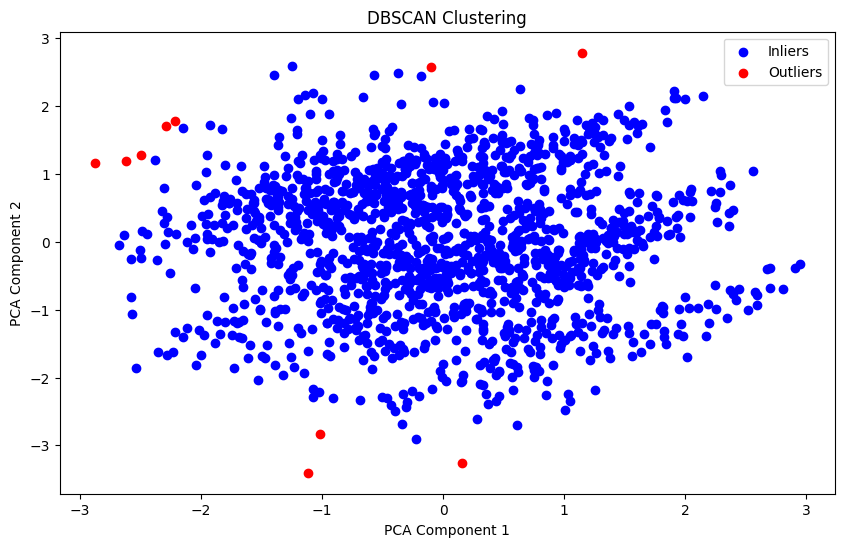

In [41]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters = dbscan.fit_predict(pca_data)
df['Cluster'] = clusters

# Identify outliers
outliers = df[df['Cluster'] == -1]

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[clusters != -1, 0], pca_data[clusters != -1, 1], c='blue', label='Inliers')
plt.scatter(pca_data[clusters == -1, 0], pca_data[clusters == -1, 1], c='red', label='Outliers')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()

In [63]:
df

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,Department,Gender,MaritalStatus
0,41,1102,1,2,2,0,Single
1,49,279,8,3,1,1,Married
2,37,1373,2,4,1,1,Single
3,33,1392,3,4,1,0,Married
4,27,591,2,1,1,1,Married
...,...,...,...,...,...,...,...
1465,36,884,23,3,1,1,Married
1466,39,613,6,4,1,1,Married
1467,27,155,4,2,1,1,Married
1468,49,1023,2,4,2,1,Married


Index([], dtype='object')

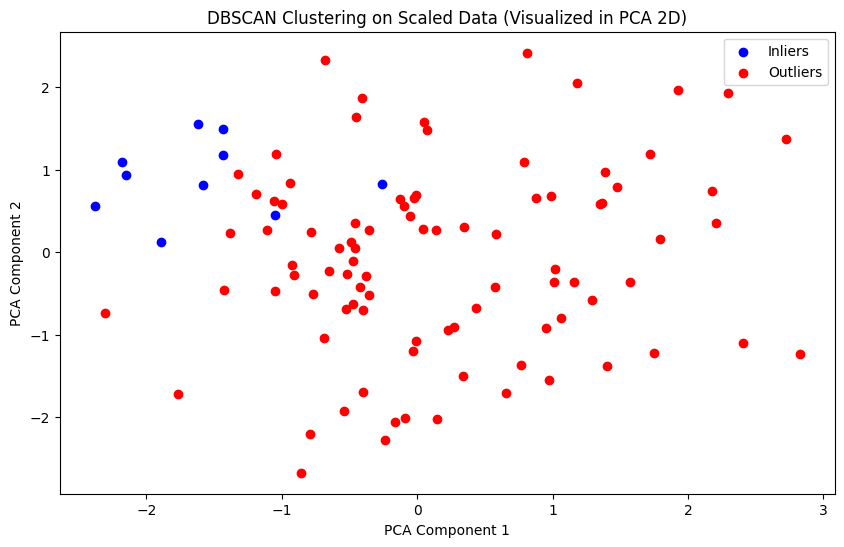

In [75]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
df_raw = pd.read_csv('/Users/navid/Documents/1_Projects/0_Age-It/Our Tasks/Privacy/WA_Fn-UseC_-HR-Employee-Attrition.csv')


keep = [
    'Age', 'DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction',
    'Department', 'Gender', 'MaritalStatus'
]

df = df_raw[keep]
df = df.sample(100, random_state=42)

# Encode categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns = ['Department', 'Gender', 'MaritalStatus']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply DBSCAN on scaled data
dbscan = DBSCAN(eps=1.7, min_samples=10)
clusters = dbscan.fit_predict(scaled_data)

# Add cluster labels to the original DataFrame
#df['Cluster'] = clusters

# Identify outliers
#outliers = df[df['Cluster'] == -1]



# Apply PCA to reduce scaled data to 2D for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[clusters != -1, 0], pca_data[clusters != -1, 1], c='blue', label='Inliers')
plt.scatter(pca_data[clusters == -1, 0], pca_data[clusters == -1, 1], c='red', label='Outliers')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clustering on Scaled Data (Visualized in PCA 2D)')
plt.legend()
plt.show()

In [81]:
from sklearn.cluster import DBSCAN
import numpy as np

# Define the parameter grid
param_grid = {
    'eps': [x/10 for x in range(1, 30, 1)],
    'min_samples': range(3, 20)
}

best_score = -1
best_params = None

# Loop through all combinations of eps and min_samples
for eps in param_grid['eps']:
    for min_samples in param_grid['min_samples']:
        # Initialize DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        
        # Fit DBSCAN to the data
        labels = dbscan.fit_predict(scaled_data)
        
        # Calculate the proportion of outliers
        n_outliers = np.sum(labels == -1)
        outlier_ratio = n_outliers / len(labels)
        
        # Use outlier ratio as the "score" (or flip it if looking to minimize outliers)
        score = outlier_ratio
        print(f"Params: eps={eps}, min_samples={min_samples}, Outlier Ratio={score}")
        
        # Update best parameters if the current score is better
        if score > best_score:
            best_score = score
            best_params = {'eps': eps, 'min_samples': min_samples}

print(f"Best Parameters for Outlier Detection: {best_params}")
print(f"Highest Outlier Ratio: {best_score}")

Params: eps=0.1, min_samples=3, Outlier Ratio=1.0
Params: eps=0.1, min_samples=4, Outlier Ratio=1.0
Params: eps=0.1, min_samples=5, Outlier Ratio=1.0
Params: eps=0.1, min_samples=6, Outlier Ratio=1.0
Params: eps=0.1, min_samples=7, Outlier Ratio=1.0
Params: eps=0.1, min_samples=8, Outlier Ratio=1.0
Params: eps=0.1, min_samples=9, Outlier Ratio=1.0
Params: eps=0.1, min_samples=10, Outlier Ratio=1.0
Params: eps=0.1, min_samples=11, Outlier Ratio=1.0
Params: eps=0.1, min_samples=12, Outlier Ratio=1.0
Params: eps=0.1, min_samples=13, Outlier Ratio=1.0
Params: eps=0.1, min_samples=14, Outlier Ratio=1.0
Params: eps=0.1, min_samples=15, Outlier Ratio=1.0
Params: eps=0.1, min_samples=16, Outlier Ratio=1.0
Params: eps=0.1, min_samples=17, Outlier Ratio=1.0
Params: eps=0.1, min_samples=18, Outlier Ratio=1.0
Params: eps=0.1, min_samples=19, Outlier Ratio=1.0
Params: eps=0.2, min_samples=3, Outlier Ratio=1.0
Params: eps=0.2, min_samples=4, Outlier Ratio=1.0
Params: eps=0.2, min_samples=5, Outlier 

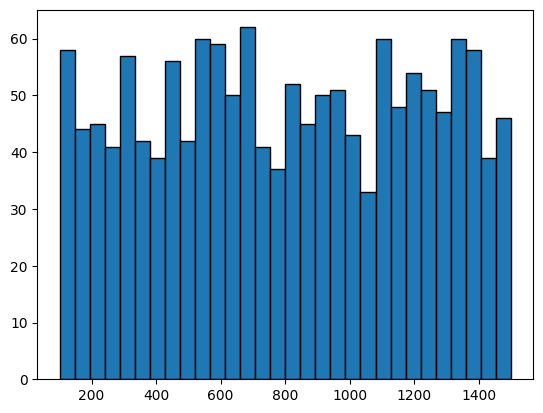

In [47]:
plt.hist(df['DailyRate'], bins=30, edgecolor='k')
plt.show()

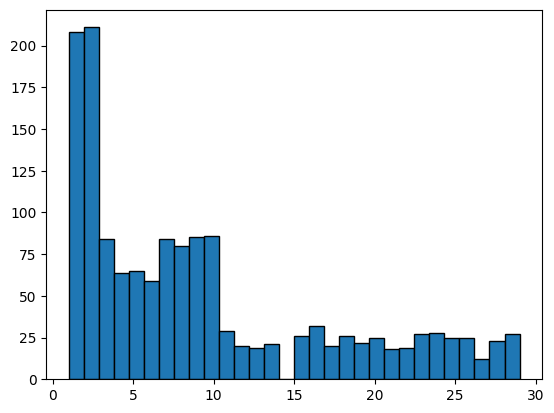

In [48]:
plt.hist(df['DistanceFromHome'], bins=30, edgecolor='k')
plt.show()

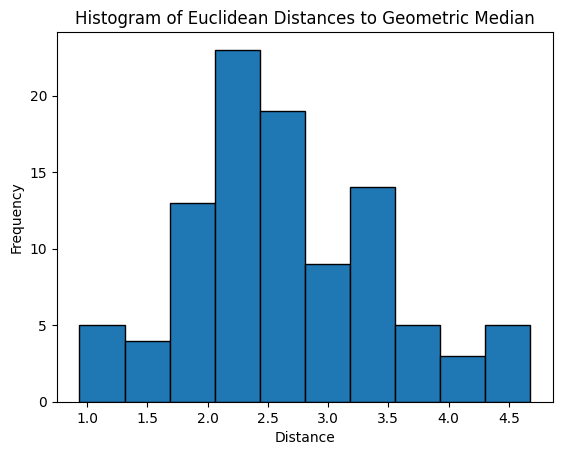

In [84]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from category_encoders.hashing import HashingEncoder
from scipy.spatial.distance import euclidean
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Step 1: Create a Dataset
# Generate a dataset with 100 samples, 5 numerical features, and 2 categorical features
X_num, _ = make_classification(n_samples=100, n_features=5, random_state=42)
# Create categorical features
np.random.seed(42)
X_cat = np.random.choice(['A', 'B', 'C'], size=(100, 2))
# Combine numerical and categorical features into a DataFrame
df = pd.DataFrame(np.hstack((X_num, X_cat)), columns=[f'num_{i}' for i in range(5)] + ['cat_1', 'cat_2'])

# Step 2: Encode Categorical Variables using HashingEncoder
encoder = HashingEncoder(n_components=4)  # Example of 4 hash features
encoded_cat = encoder.fit_transform(df[['cat_1', 'cat_2']])
# Combine encoded categorical features with numerical features
df_encoded = pd.concat([df.drop(['cat_1', 'cat_2'], axis=1), encoded_cat], axis=1)

# Step 3: Calculate the Geometric Median
def geometric_median(X, eps=1e-5):
    y = np.mean(X, axis=0)
    while True:
        D = np.linalg.norm(X - y, axis=1)
        nonzeros = (D != 0)
        D_inv = 1 / D[nonzeros]
        W = D_inv / D_inv.sum()
        T = (W[:, np.newaxis] * X[nonzeros]).sum(axis=0)
        num_zeros = len(X) - np.sum(nonzeros)
        if num_zeros == 0:
            y1 = T
        elif num_zeros == len(X):
            return y
        else:
            R = (T - y) * np.sum(D_inv)
            r = np.linalg.norm(R)
            rinv = 0 if r == 0 else num_zeros / r
            y1 = max(0, 1 - rinv) * T + min(1, rinv) * y
        if np.linalg.norm(y - y1) < eps:
            return y1
        y = y1

# Convert DataFrame to NumPy array for computation
X_encoded = df_encoded.to_numpy().astype(float)
geo_median = geometric_median(X_encoded)

# Step 4: Compute Euclidean Distances
distances = np.array([euclidean(point, geo_median) for point in X_encoded])

# Step 5: Plot a Histogram of Distances
plt.hist(distances, bins=10, edgecolor='black')
plt.title('Histogram of Euclidean Distances to Geometric Median')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

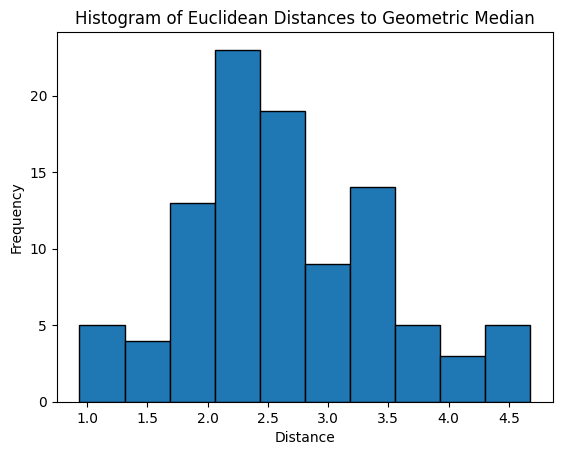

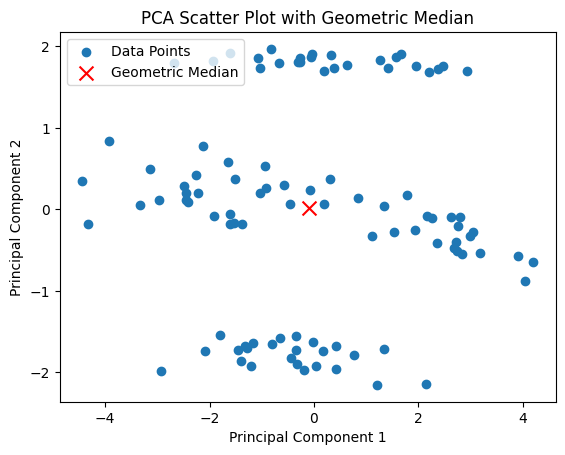

In [85]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from category_encoders.hashing import HashingEncoder
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Create a Dataset
X_num, _ = make_classification(n_samples=100, n_features=5, random_state=42)
np.random.seed(42)
X_cat = np.random.choice(['A', 'B', 'C'], size=(100, 2))
df = pd.DataFrame(np.hstack((X_num, X_cat)), columns=[f'num_{i}' for i in range(5)] + ['cat_1', 'cat_2'])

# Step 2: Encode Categorical Variables using HashingEncoder
encoder = HashingEncoder(n_components=4)
encoded_cat = encoder.fit_transform(df[['cat_1', 'cat_2']])
df_encoded = pd.concat([df.drop(['cat_1', 'cat_2'], axis=1), encoded_cat], axis=1)

# Step 3: Calculate the Geometric Median
def geometric_median(X, eps=1e-5):
    y = np.mean(X, axis=0)
    while True:
        D = np.linalg.norm(X - y, axis=1)
        nonzeros = (D != 0)
        D_inv = 1 / D[nonzeros]
        W = D_inv / D_inv.sum()
        T = (W[:, np.newaxis] * X[nonzeros]).sum(axis=0)
        num_zeros = len(X) - np.sum(nonzeros)
        if num_zeros == 0:
            y1 = T
        elif num_zeros == len(X):
            return y
        else:
            R = (T - y) * np.sum(D_inv)
            r = np.linalg.norm(R)
            rinv = 0 if r == 0 else num_zeros / r
            y1 = max(0, 1 - rinv) * T + min(1, rinv) * y
        if np.linalg.norm(y - y1) < eps:
            return y1
        y = y1

X_encoded = df_encoded.to_numpy().astype(float)
geo_median = geometric_median(X_encoded)

# Step 4: Compute Euclidean Distances
distances = np.array([euclidean(point, geo_median) for point in X_encoded])

# Step 5: Plot a Histogram of Distances
plt.hist(distances, bins=10, edgecolor='black')
plt.title('Histogram of Euclidean Distances to Geometric Median')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

# Step 6: PCA Scatter Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# Plot PCA scatter with geometric median highlighted
plt.scatter(X_pca[:, 0], X_pca[:, 1], label='Data Points')
geo_median_pca = pca.transform(geo_median.reshape(1, -1))
plt.scatter(geo_median_pca[:, 0], geo_median_pca[:, 1], color='red', marker='x', s=100, label='Geometric Median')
plt.title('PCA Scatter Plot with Geometric Median')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

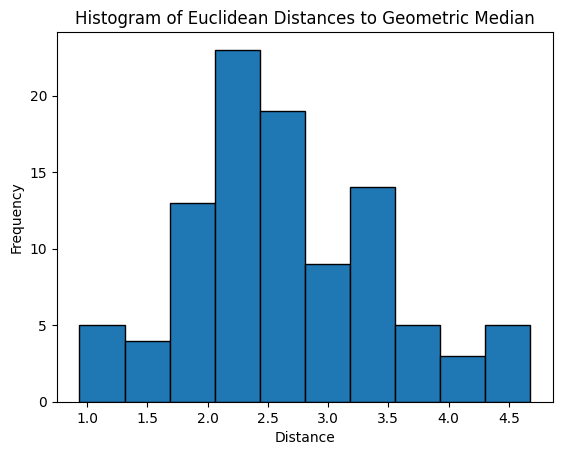

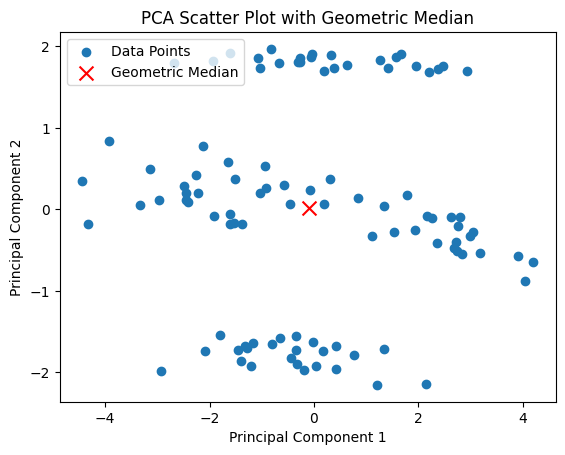

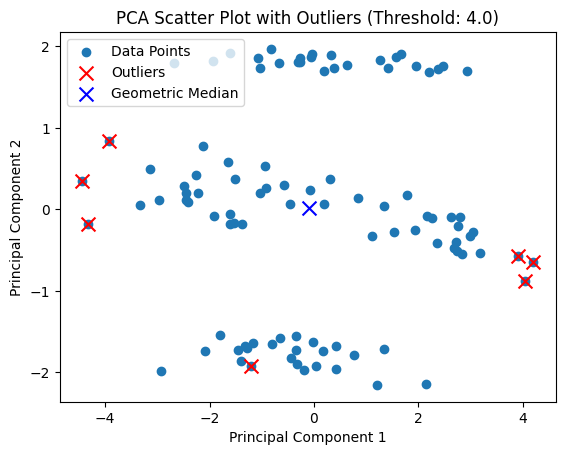

In [87]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from category_encoders.hashing import HashingEncoder
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Create a Dataset
X_num, _ = make_classification(n_samples=100, n_features=5, random_state=42)
np.random.seed(42)
X_cat = np.random.choice(['A', 'B', 'C'], size=(100, 2))
df = pd.DataFrame(np.hstack((X_num, X_cat)), columns=[f'num_{i}' for i in range(5)] + ['cat_1', 'cat_2'])

# Step 2: Encode Categorical Variables using HashingEncoder
encoder = HashingEncoder(n_components=4)
encoded_cat = encoder.fit_transform(df[['cat_1', 'cat_2']])
df_encoded = pd.concat([df.drop(['cat_1', 'cat_2'], axis=1), encoded_cat], axis=1)

# Step 3: Calculate the Geometric Median
def geometric_median(X, eps=1e-5):
    y = np.mean(X, axis=0)
    while True:
        D = np.linalg.norm(X - y, axis=1)
        nonzeros = (D != 0)
        D_inv = 1 / D[nonzeros]
        W = D_inv / D_inv.sum()
        T = (W[:, np.newaxis] * X[nonzeros]).sum(axis=0)
        num_zeros = len(X) - np.sum(nonzeros)
        if num_zeros == 0:
            y1 = T
        elif num_zeros == len(X):
            return y
        else:
            R = (T - y) * np.sum(D_inv)
            r = np.linalg.norm(R)
            rinv = 0 if r == 0 else num_zeros / r
            y1 = max(0, 1 - rinv) * T + min(1, rinv) * y
        if np.linalg.norm(y - y1) < eps:
            return y1
        y = y1

X_encoded = df_encoded.to_numpy().astype(float)
geo_median = geometric_median(X_encoded)

# Step 4: Compute Euclidean Distances
distances = np.array([euclidean(point, geo_median) for point in X_encoded])

# Step 5: Plot a Histogram of Distances
plt.hist(distances, bins=10, edgecolor='black')
plt.title('Histogram of Euclidean Distances to Geometric Median')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

# Step 6: PCA Scatter Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# Scatter plot with geometric median
geo_median_pca = pca.transform(geo_median.reshape(1, -1))
plt.scatter(X_pca[:, 0], X_pca[:, 1], label='Data Points')
plt.scatter(geo_median_pca[:, 0], geo_median_pca[:, 1], color='red', marker='x', s=100, label='Geometric Median')
plt.title('PCA Scatter Plot with Geometric Median')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Step 7: Identify Outliers
threshold = 4.0  # Set the threshold for identifying outliers
outliers = distances > threshold
outliers_pca = X_pca[outliers]

# Plot PCA scatter with outliers highlighted
plt.scatter(X_pca[:, 0], X_pca[:, 1], label='Data Points')
plt.scatter(outliers_pca[:, 0], outliers_pca[:, 1], color='red', marker='x', s=100, label='Outliers')
plt.scatter(geo_median_pca[:, 0], geo_median_pca[:, 1], color='blue', marker='x', s=100, label='Geometric Median')
plt.title(f'PCA Scatter Plot with Outliers (Threshold: {threshold})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()